In [1]:
cd ..

d:\Datathon


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\Khang\AppData\Local\Temp\ipykernel_20044\2080847977.py:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(path + 'order_items.csv')


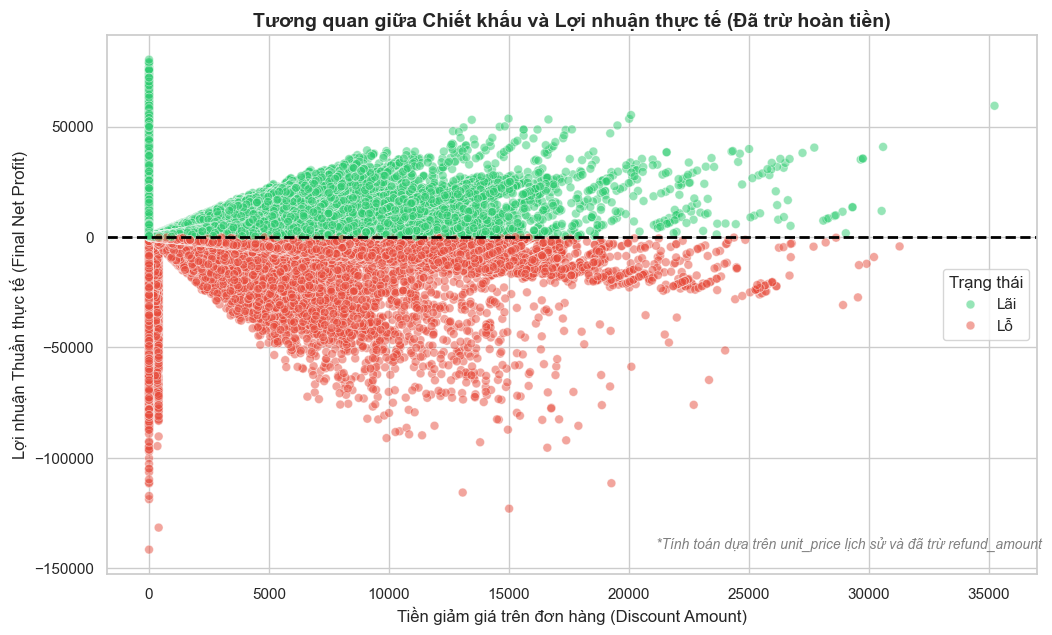

Tổng số giao dịch bị lỗ ròng thực tế: 162,368 đơn hàng


In [2]:

# 1. Nạp dữ liệu 
path = "Data/"
order_items = pd.read_csv(path + 'order_items.csv')
products = pd.read_csv(path + 'products.csv')
returns = pd.read_csv(path + 'returns.csv')

# 2. Hợp nhất dữ liệu
df_master = pd.merge(order_items, products[['product_id', 'price', 'cogs', 'segment']], on='product_id', how='left')

# Nối với returns để lấy thông t oy in hoàn tiền (refund_amount)
df_master = pd.merge(df_master, returns[['order_id', 'product_id', 'refund_amount']],
                     on=['order_id', 'product_id'], how='left')

# Xử lý giá trị trống: Nếu không có trong bảng returns nghĩa là không hoàn tiền (refund = 0)
df_master['refund_amount'] = df_master['refund_amount'].fillna(0)

# A. Doanh thu NIÊM YẾT
df_master['potential_revenue'] = df_master['quantity'] * df_master['price']

# B. Doanh thu THỰC THU
df_master['actual_revenue'] = df_master['quantity'] * df_master['unit_price']

# C. Doanh thu THUẦN
df_master['net_sales'] = df_master['actual_revenue'] - df_master['refund_amount']

# D. Tổng giá vốn (Total COGS)
df_master['total_cogs'] = df_master['quantity'] * df_master['cogs']

# E. LỢI NHUẬN THUẦN CUỐI CÙNG (Final Net Profit)
# Công thức: Tiền thực cầm về - Tiền vốn bỏ ra
df_master['final_net_profit'] = df_master['net_sales'] - df_master['total_cogs']

# 4. Phân loại Lỗ/Lãi dựa trên Lợi nhuận cuối cùng
df_master['Trạng thái'] = df_master['final_net_profit'].apply(lambda x: 'Lỗ' if x < 0 else 'Lãi')

# 5. Trực quan hóa Biểu đồ 1 (Cập nhật logic mới)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Vẽ Scatter Plot: x là discount_amount (tác nhân), y là final_net_profit (kết quả)
sns.scatterplot(data=df_master, x='discount_amount', y='final_net_profit',
                hue='Trạng thái', palette={'Lãi': '#2ecc71', 'Lỗ': '#e74c3c'},
                alpha=0.5, edgecolor='w', s=40)

# Đường Sinh Tử (Lợi nhuận = 0)
plt.axhline(0, color='black', linestyle='--', linewidth=2)

plt.title('Tương quan giữa Chiết khấu và Lợi nhuận thực tế (Đã trừ hoàn tiền)', fontsize=14, fontweight='bold')
plt.xlabel('Tiền giảm giá trên đơn hàng (Discount Amount)', fontsize=12)
plt.ylabel('Lợi nhuận Thuần thực tế (Final Net Profit)', fontsize=12)

# Thêm chú thích về ý nghĩa của việc dùng unit_price và refund
plt.text(df_master['discount_amount'].max()*0.6, df_master['final_net_profit'].min(),
         "*Tính toán dựa trên unit_price lịch sử và đã trừ refund_amount",
         fontsize=10, color='gray', style='italic')

plt.show()

# In thống kê nhanh để kiểm tra "Insight" cho Thanh
loss_count = len(df_master[df_master['final_net_profit'] < 0])
print(f"Tổng số giao dịch bị lỗ ròng thực tế: {loss_count:,} đơn hàng")

# Biểu đồ 2

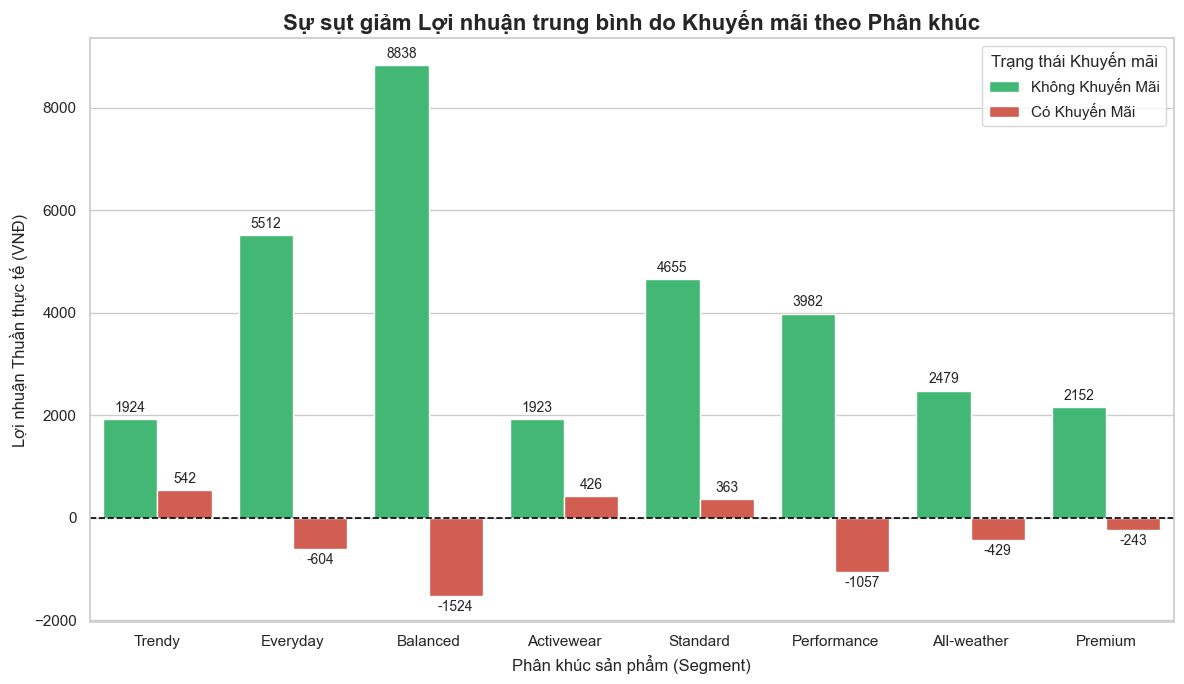

In [4]:
# 1. Tạo cột phân loại "Có mã" hay "Không mã"
df_master['Has_Promo'] = df_master['discount_amount'].apply(
    lambda x: 'Có Khuyến Mãi' if x > 0 else 'Không Khuyến Mãi'
)

# 2. Thiết lập khung vẽ
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_master, x='segment', y='final_net_profit', hue='Has_Promo',
                 palette={'Có Khuyến Mãi': '#e74c3c', 'Không Khuyến Mãi': '#2ecc71'},
                 errorbar=None)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, size=10) # fmt='%.0f' để làm tròn số nguyên

plt.axhline(0, color='black', linestyle='--', linewidth=1.2)
plt.title('Sự sụt giảm Lợi nhuận trung bình do Khuyến mãi theo Phân khúc', fontsize=16, fontweight='bold')
plt.xlabel('Phân khúc sản phẩm (Segment)', fontsize=12)
plt.ylabel('Lợi nhuận Thuần thực tế (VNĐ)', fontsize=12)
plt.legend(title='Trạng thái Khuyến mãi', fontsize=11)

plt.tight_layout()
plt.show()

# Biểu đồ 3

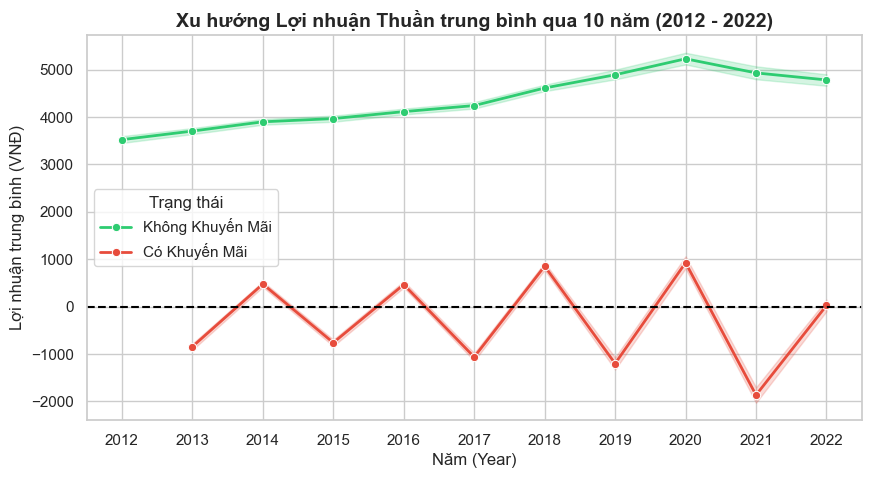

In [6]:

# 1. Đọc thêm bảng orders để lấy thời gian
orders = pd.read_csv(path + 'orders.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Year'] = orders['order_date'].dt.year # Trích xuất Năm

# 2. Nối thông tin Năm vào bảng df_master hiện tại
df_trend = pd.merge(df_master, orders[['order_id', 'Year']], on='order_id', how='inner')

# 3. Vẽ Biểu đồ xu hướng (Trend)
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Vẽ đường Lợi nhuận của nhóm "Có khuyến mãi" và "Không khuyến mãi" qua 10 năm
sns.lineplot(data=df_trend, x='Year', y='final_net_profit', hue='Has_Promo',
             palette={'Có Khuyến Mãi': '#e74c3c', 'Không Khuyến Mãi': '#2ecc71'},
             marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Xu hướng Lợi nhuận Thuần trung bình qua 10 năm (2012 - 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Năm (Year)', fontsize=12)
plt.ylabel('Lợi nhuận trung bình (VNĐ)', fontsize=12)
plt.xticks(range(2012, 2023)) # Hiển thị đủ các năm
plt.legend(title='Trạng thái')

plt.show()
